<font color="FF3B3B"><h1 align="left">Proyecto de aprendizaje profundo</h1></font>
<font color="#6E6E6E"><h2 align="left">Modelo complejo CNN Nº 7</h2></font>

##### David Alejandro Pedroza De Jesús
##### Joel Ezequiel Vicente Alonso

Cargamos las librerias para la realización del proyecto

In [3]:
import sys
sys.path.append("../")
from CNNComplejo12 import ModeloComplejo
import numpy as np
import pandas as pd
import cv2
import kagglehub
import os
from shutil import move
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.utils import plot_model

In [4]:
path = kagglehub.dataset_download("gpiosenka/cards-image-datasetclassification")
print(path)

Using Colab cache for faster access to the 'cards-image-datasetclassification' dataset.
/kaggle/input/cards-image-datasetclassification


In [5]:
move(path,os.getcwd())

OSError: [Errno 30] Read-only file system: '/kaggle/input/cards-image-datasetclassification'

In [ ]:
os.rename("2","cards-image-datasetclassification")

# Resumen

En este caso hemos decidico probar aplicando un upsampling, el cual es una capa que es contraria a la convolución, para ver si da buenos resultados.

# Cargar las imagenes

Hararemos el procesado que hemos hecho antes, tanto con las etiquetas e imagenes.

In [6]:
datos = pd.read_csv(r"cards-image-datasetclassification/cards.csv")
datos.head()

,class index,filepaths,labels,card type,data set
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train


Arreglamos las rutas.

In [7]:
rutas_adaptadas = ["cards-image-datasetclassification/" +  ruta for ruta in datos["filepaths"]]
im_buenas = []
im_malas = []
for ru in rutas_adaptadas:
    im = cv2.imread(ru)
    if  im is not None:
        im_buenas.append(ru)
    else:
        im_malas.append(ru)
#print(f"Lecturas correctas: {len(im_buenas)}")
#print(f"Lecturas incorrectas: {len(im_malas)}")

df_limpio = datos[np.array(rutas_adaptadas) != np.array(im_malas)]
df_limpio["rutas_adap"] = im_buenas

/tmp/ipykernel_1916/1813950221.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio["rutas_adap"] = im_buenas


Ahora cargamos las imagenes, añadiremos un procesado más, debido a que no necesitamos toda la carta para realizar la predicción.

In [8]:
def CargarImg(path, size):
    img = cv2.imread(path)
    img_RGB = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)[0:75,0:75]#De con esto ya tenemos toda la información
    img_resize = cv2.resize(img_RGB, size)
    return np.array(img_resize / 255.)

In [9]:
rutas_train = df_limpio[df_limpio["data set"] == "train"].rutas_adap
rutas_test = df_limpio[df_limpio["data set"] == "test"].rutas_adap
rutas_val = df_limpio[df_limpio["data set"] == "valid"].rutas_adap

X_train = np.array([CargarImg(path, (75, 75)) for path in rutas_train])
X_test = np.array([CargarImg(path, (75, 75)) for path in rutas_test])
X_val = np.array([CargarImg(path, (75, 75)) for path in rutas_val])

y_train = df_limpio[df_limpio["data set"] == "train"]["labels"]
y_test = df_limpio[df_limpio["data set"] == "test"]["labels"]
y_val = df_limpio[df_limpio["data set"] == "valid"]["labels"]

Y codificamos los labels con `LabelEncoder()`

In [10]:
encoder = LabelEncoder()

y_train_num = encoder.fit_transform(y_train)
y_val_num   = encoder.transform(y_val)
y_test_num  = encoder.transform(y_test)

# Arquitectura de la red

En este apartado iremos probando la arquitectura, en este hemos añadido capas dos capas dense y dos capas convolucionales.

In [11]:
input_shape = X_train[0].shape
num_clases = np.unique(y_train_num).shape[0]
model = ModeloComplejo(input_shape, num_clases)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 75, 75, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 75, 75, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 37, 37, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 74, 74, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 74, 74, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5184)           │             

 Total params: 395,765 (1.51 MB)

 Trainable params: 395,349 (1.51 MB)

 Non-trainable params: 416 (1.62 KB)

También aquí hacemos un plot de la arquitectura del modelo.

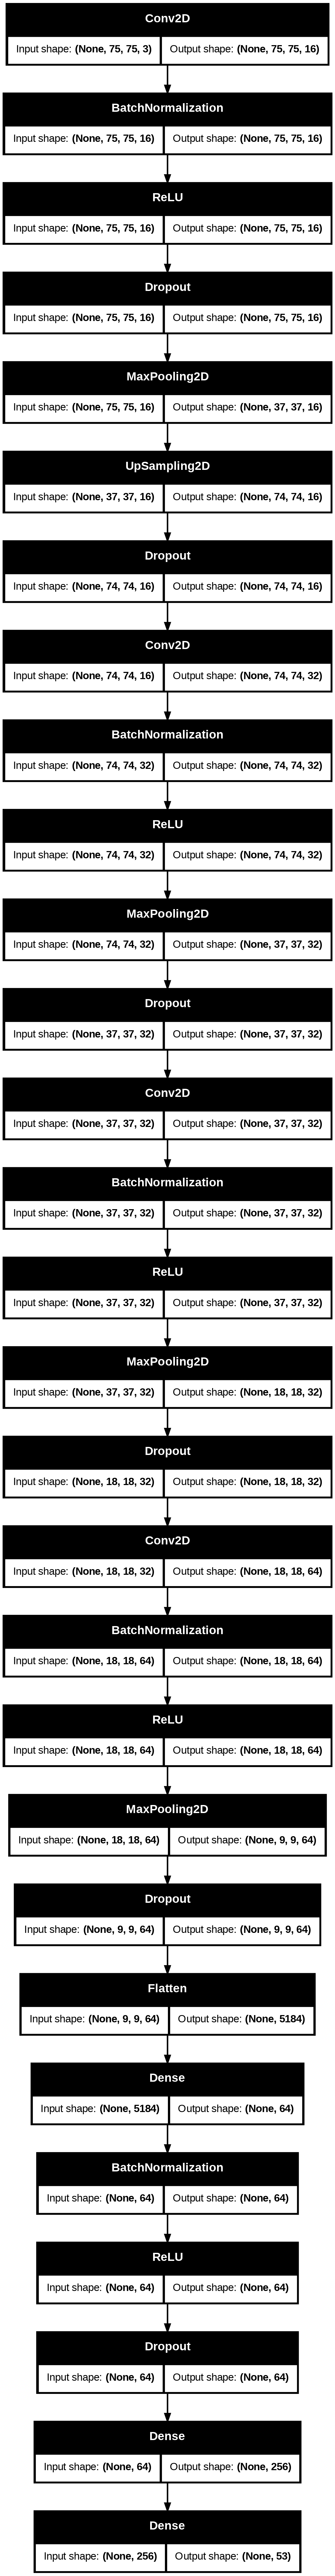

In [12]:
plot_model(model, show_shapes=True)

# Entrenamiento

En este apartado realizaremos el entrenamiento.

In [13]:
hist = model.fit(X_train, y_train_num,validation_data=(X_val, y_val_num), epochs=350)

Epoch 1/350
239/239 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - loss: 3.6061 - sparse_categorical_accuracy: 0.0675 - val_loss: 4.1660 - val_sparse_categorical_accuracy: 0.0340
Epoch 2/350
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3.0639 - sparse_categorical_accuracy: 0.1455 - val_loss: 2.7290 - val_sparse_categorical_accuracy: 0.2264
Epoch 3/350
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.7012 - sparse_categorical_accuracy: 0.2286 - val_loss: 2.2446 - val_sparse_categorical_accuracy: 0.2906
Epoch 4/350
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.3915 - sparse_categorical_accuracy: 0.3118 - val_loss: 1.6201 - val_sparse_categorical_accuracy: 0.5132
Epoch 5/350
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.1460 - sparse_categorical_accuracy: 0.3760 - val_loss: 1.2860 - val_sparse_categorical_accuracy: 0.6453
Epoch 6/350
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.9228 - sparse_categorical_accuracy: 0.4431 - val_loss: 1.1519 - val_sparse_categorical_accuracy

# Evaluación del modelo

La evolución del modelo es lenta y el error de validación no baja, lo que indica sobre ajuste.

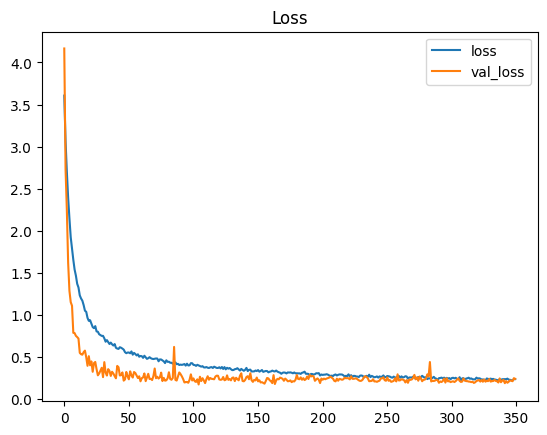

In [14]:
loss = hist.history["loss"]
val_loss = hist.history["val_loss"]

plt.plot(loss, label="loss")
plt.plot(val_loss, label="val_loss")
plt.title("Loss")
plt.legend()
plt.show()

El acc del conjunto de validación no crece.

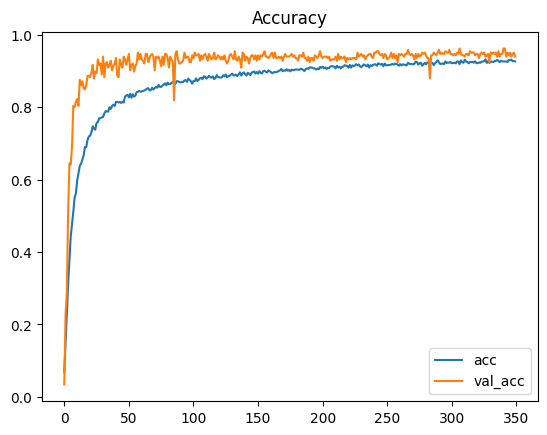

In [23]:
acc = hist.history["sparse_categorical_accuracy"]
val_acc = hist.history["val_sparse_categorical_accuracy"]

plt.plot(acc, label="acc")
plt.plot(val_acc, label="val_acc")
plt.title("Accuracy")
plt.legend()
plt.show()

Aquí podemos ver que el modelo solo funciona bien en el conjunto de entrenamiento, lo que demuestra el sobreajuste.

In [24]:

train_loss, train_acc = model.evaluate(X_train, y_train_num, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val_num, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_num, verbose=0)

print("TRAIN:")
print("Loss:", round(train_loss,3))
print("Accuracy:", round(train_acc,3))

print("\nVALIDATION:")
print("Loss:", round(val_loss,3))
print("Accuracy:", round(val_acc,3))

print("\nTEST:")
print("Loss:", round(test_loss,3))
print("Accuracy:", round(test_acc,3))

TRAIN:
Loss: 0.048
Accuracy: 0.989

VALIDATION:
Loss: 0.24
Accuracy: 0.94

TEST:
Loss: 0.38
Accuracy: 0.909


# Matriz de confución

Aquí podemos ver la matriz de confución del modelo y funciona como se espera.

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


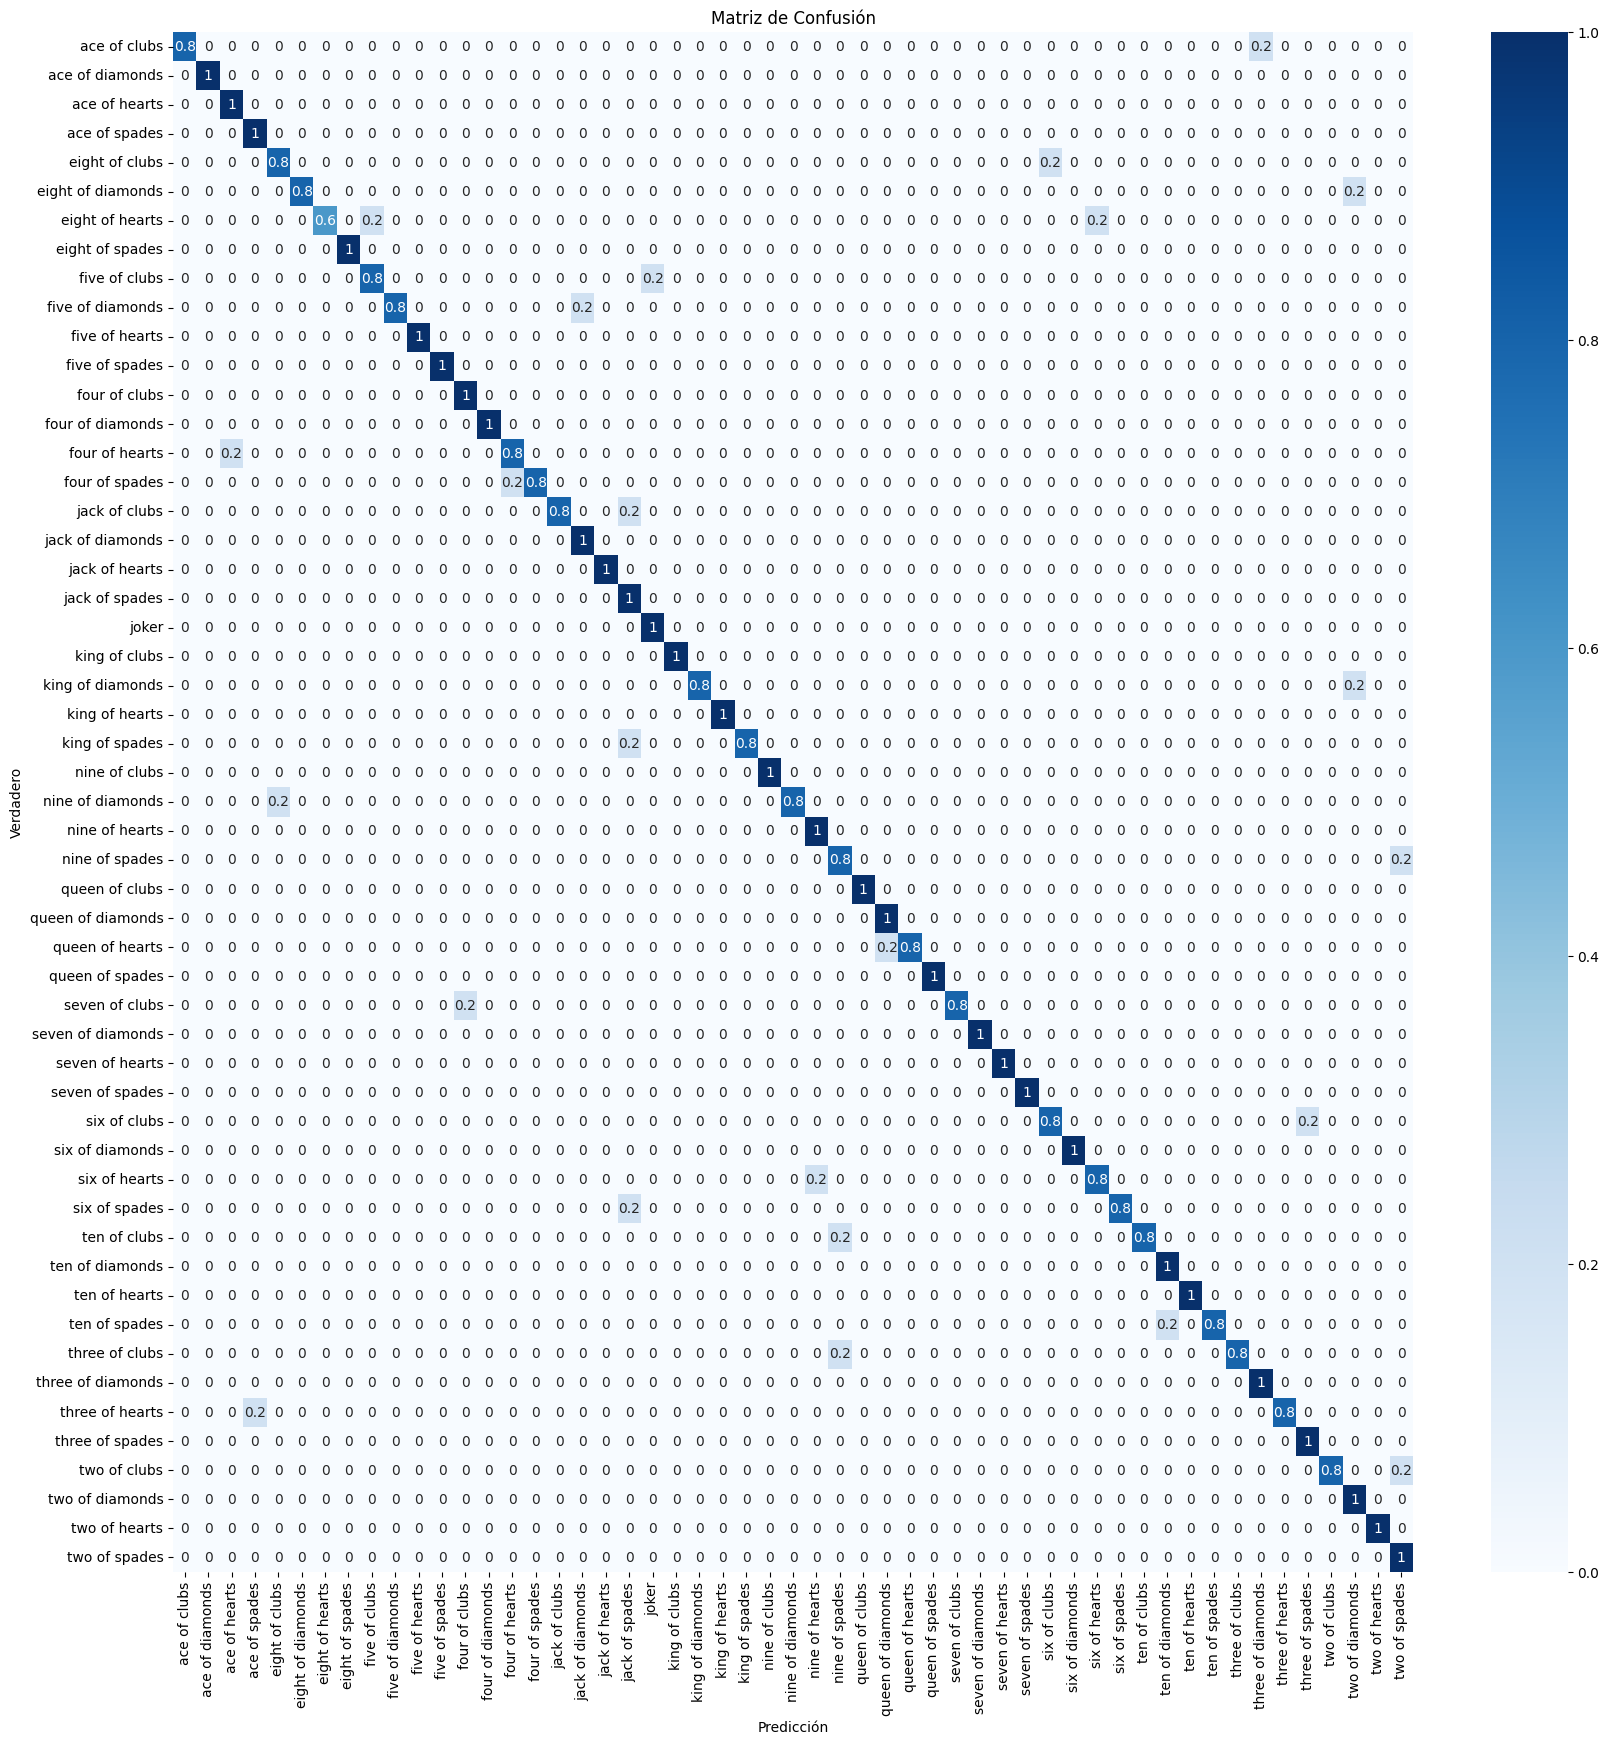

In [25]:
class_names = encoder.classes_

cm = confusion_matrix(y_test_num, np.argmax(model.predict(X_test), axis=1), normalize="true")

plt.figure(figsize=(20, 20))
sns.heatmap(cm,
            annot=True, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)

plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión')
plt.yticks(rotation=0)
plt.show()

# Conclusión

El modelo aun parece tener margen de mejora, el proximo paso podría ser añadir más capas o incluso regularizar un poco más.

In [87]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def cargar_img_individual(num,path, size=(75, 75)):
    img = cv2.imread(path)
    im2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(im2)
    plt.show()
    if img is None:
        raise ValueError(f"No se pudo cargar la imagen: {path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[0:num, 0:num]
    img_resize = cv2.resize(img_rgb, size)
    img_norm = img_resize / 255.0

    return img_norm

def predecir_imagen(num,path, model, encoder, size=(75, 75), mostrar=True):
    # Preprocesado
    img = cargar_img_individual(num,path, size)

    # Añadir dimensión batch: (75,75,3) -> (1,75,75,3)
    img_batch = np.expand_dims(img, axis=0)

    # Predicción
    pred = model.predict(img_batch, verbose=0)
    clase_idx = np.argmax(pred, axis=1)[0]
    clase_nombre = encoder.inverse_transform([clase_idx])[0]
    confianza = pred[0][clase_idx]

    if mostrar:
        plt.imshow(img)
        plt.title(f"Predicción: {clase_nombre} | Confianza: {confianza:.4f}")
        plt.axis("off")
        plt.show()

    return clase_nombre, confianza, pred[0]

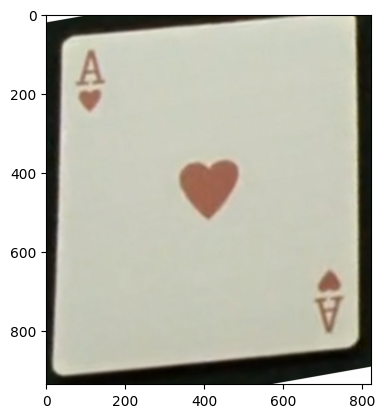

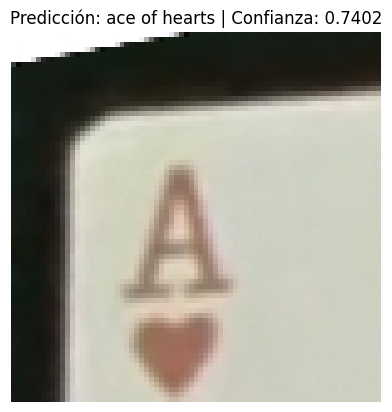

Clase predicha: ace of hearts
Confianza: 0.7401817


In [94]:
ruta_prueba = "ace3.png"
clase, confianza, probabilidades = predecir_imagen(250,ruta_prueba, model, encoder)

print("Clase predicha:", clase)
print("Confianza:", confianza)

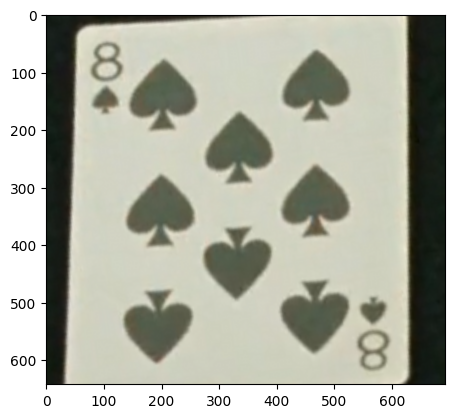

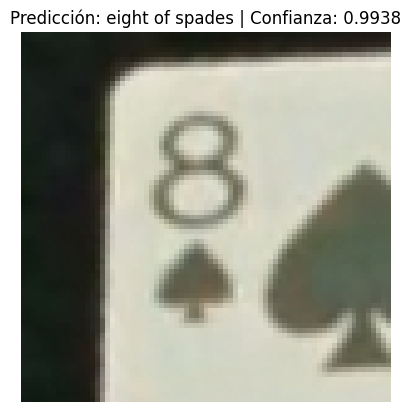

Clase predicha: eight of spades
Confianza: 0.9937724


In [95]:
ruta_prueba = "8ofspades.png"
clase, confianza, probabilidades = predecir_imagen(220,ruta_prueba, model, encoder)

print("Clase predicha:", clase)
print("Confianza:", confianza)

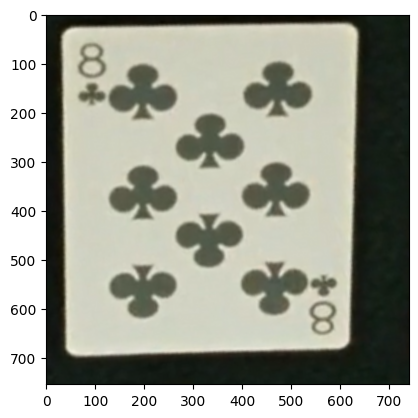

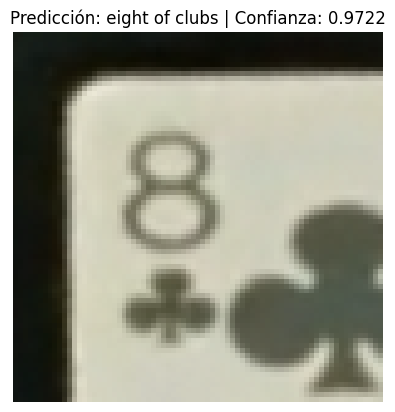

Clase predicha: eight of clubs
Confianza: 0.9722066


In [96]:
ruta_prueba = "8ofclubs.png"
clase, confianza, probabilidades = predecir_imagen(220,ruta_prueba, model, encoder)

print("Clase predicha:", clase)
print("Confianza:", confianza)

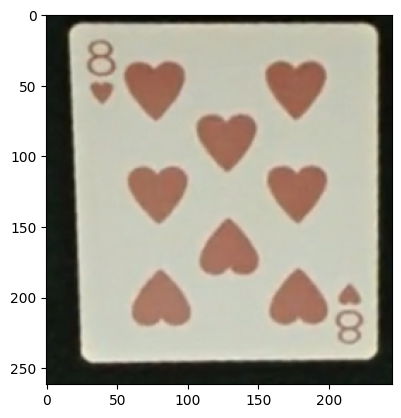

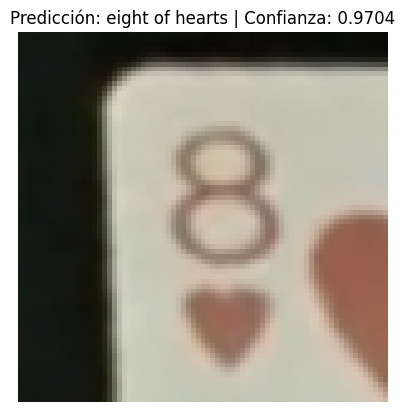

Clase predicha: eight of hearts
Confianza: 0.9703799


In [97]:
ruta_prueba = "8ofhearts.png"
clase, confianza, probabilidades = predecir_imagen(70,ruta_prueba, model, encoder)

print("Clase predicha:", clase)
print("Confianza:", confianza)

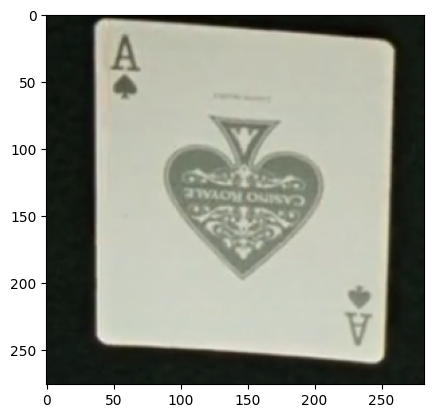

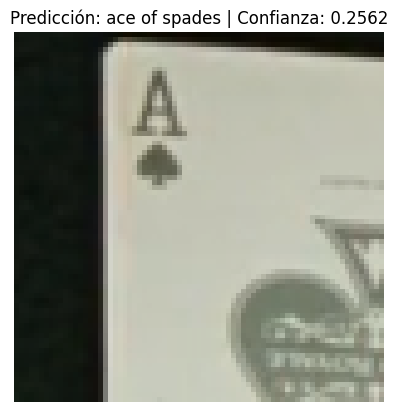

Clase predicha: ace of spades
Confianza: 0.25622448


In [92]:
ruta_prueba = "acespade.png"
clase, confianza, probabilidades = predecir_imagen(151,ruta_prueba, model, encoder)

print("Clase predicha:", clase)
print("Confianza:", confianza)

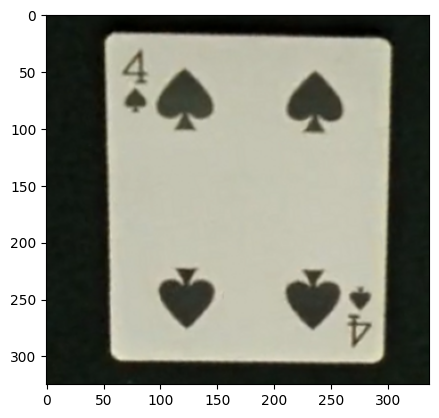

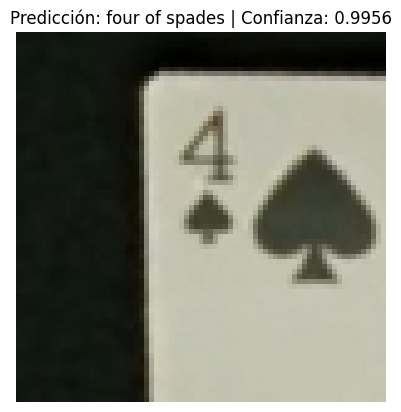

Clase predicha: four of spades
Confianza: 0.995625


In [98]:
ruta_prueba = "fourofspades.png"
clase, confianza, probabilidades = predecir_imagen(151,ruta_prueba, model, encoder)

print("Clase predicha:", clase)
print("Confianza:", confianza)

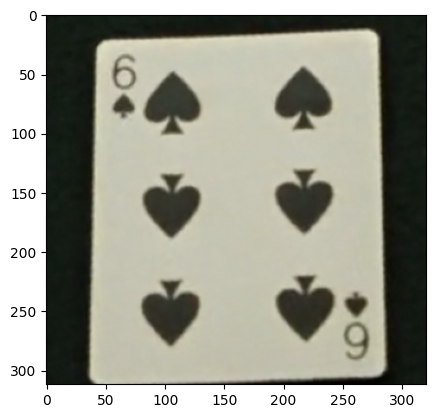

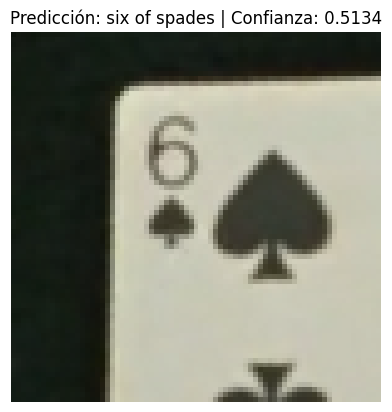

Clase predicha: six of spades
Confianza: 0.5134257


In [99]:
ruta_prueba = "sixofspades.png"
clase, confianza, probabilidades = predecir_imagen(151,ruta_prueba, model, encoder)

print("Clase predicha:", clase)
print("Confianza:", confianza)

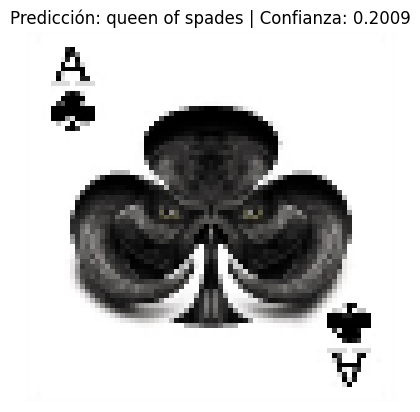

Etiqueta real: ace of clubs
Predicción: queen of spades


In [35]:
ruta_prueba = rutas_test.iloc[0]
clase, confianza, probabilidades = predecir_imagen(ruta_prueba, model, encoder)
print("Etiqueta real:", y_test.iloc[0])
print("Predicción:", clase)

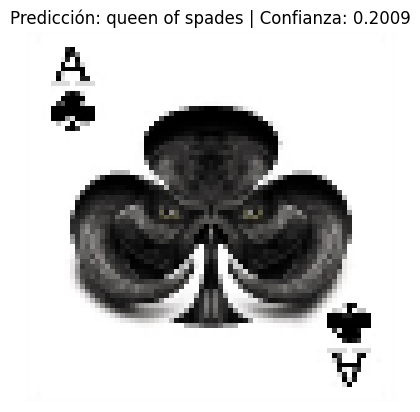

Real: ace of clubs | Predicha: queen of spades | Confianza: 0.2009


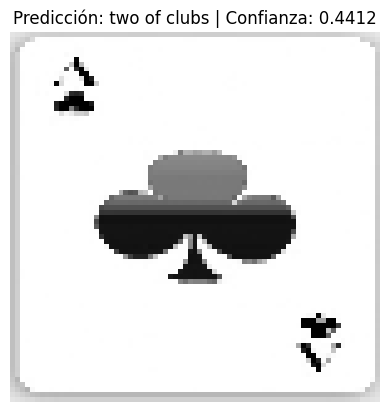

Real: ace of clubs | Predicha: two of clubs | Confianza: 0.4412


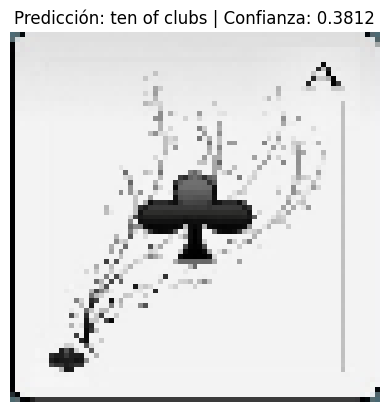

Real: ace of clubs | Predicha: ten of clubs | Confianza: 0.3812


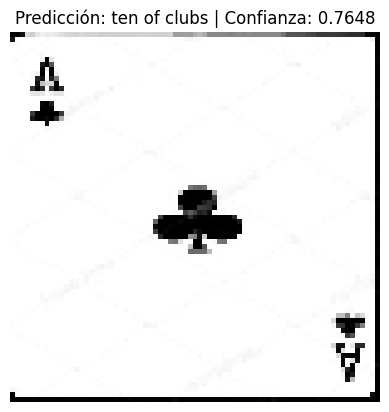

Real: ace of clubs | Predicha: ten of clubs | Confianza: 0.7648


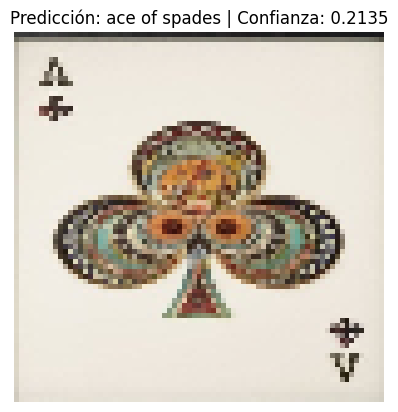

Real: ace of clubs | Predicha: ace of spades | Confianza: 0.2135


In [36]:
for i in range(5):
    ruta = rutas_test.iloc[i]
    real = y_test.iloc[i]
    predicha, confianza, _ = predecir_imagen(ruta, model, encoder, mostrar=True)
    print(f"Real: {real} | Predicha: {predicha} | Confianza: {confianza:.4f}")

Shorter for one image

Predicción: queen of spades


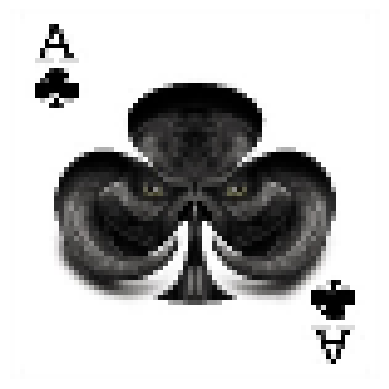

In [52]:
path = rutas_test.iloc[0]

img = cargar_img_individual(path, (75, 75))
pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
idx = np.argmax(pred, axis=1)[0]
label = encoder.inverse_transform([idx])[0]

print("Predicción:", label)
plt.imshow(img)
plt.axis("off")
plt.show()